_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: **Karim Zaghw, Kai Rothe, Mohammed Abbas Ansari**

LLM Disclaimer: Yes, ChatGPT and Copilot was used in almost all the cell blocks to produce code. Modifications was done to LLM's output and care was taken to ensure desired outcome. 

# Coding Lab 8: Neural Morphologies

## Introduction

The anatomical shape of a neuron — its morphology — has fascinated scientists ever since the pioneering work of Cajal (Ramon y Cajal, 1911). A neuron's dendritic and axonal processes naturally decide what other neurons it can connect to, hence, its shape plays an important role for its function in the circuit. In particular, different functional types of neurons have fundamentally different morphologies.

This notebook will introduce you to the analysis of neural morphologies using the dendrites of over $500$ retinal ganglion cells. The aim is to teach you two different ways of representing morphologies and give you an impression of their repsective strengths and weaknesses.

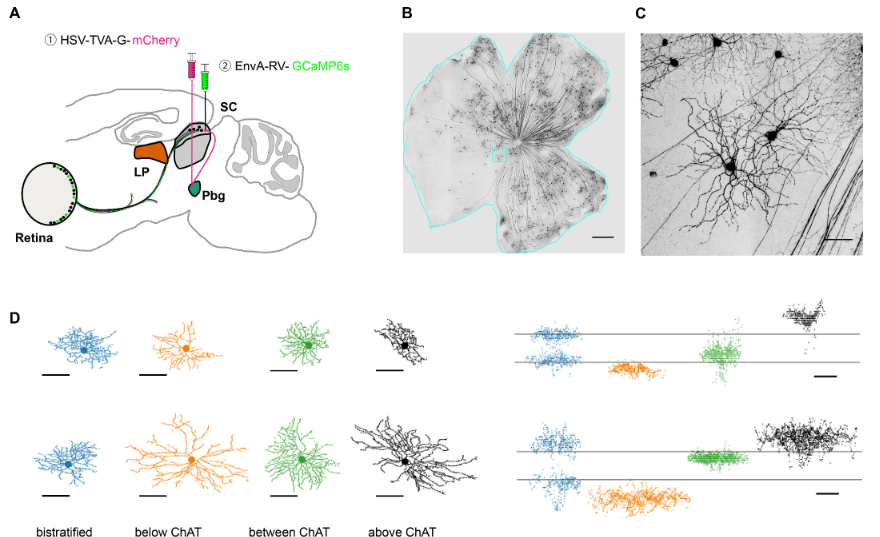

### 1. Data

The data set contains morphological reconstructions of $599$ retinal ganglion cell dendrites with cell type label and projection target to either the parabigeminal (Pbg) or the pulvinar nucleus (LP)([Reinhard et al. (2019)](https://elifesciences.org/articles/50697)). 
Here we only keep cells that map to clusters with more than six cells per cluster which leads to $550$ remaining reconstructions. 

Download the data file `nds_cl_8.zip` from ILIAS and unzip it in a subfolder `../data/`


### 2. Toolbox

We will use MorphoPy (Laturnus, et al., 2020; https://github.com/berenslab/MorphoPy) for this exercise. We recommend to use the Github version, as it is more up-to-date:

```
git clone https://github.com/berenslab/MorphoPy
pip install -e MorphoPy
```

Most of the computations and even some plottings will be handled by MorphoPy. You can learn more about MorphoPy's APIs in this [tutorial](https://nbviewer.jupyter.org/github/berenslab/MorphoPy/blob/master/notebooks/MORPHOPY%20Tutorial.ipynb). 

In [3]:
import pandas as pd
import numpy as np
import os

from morphopy.computation import file_manager
from morphopy.neurontree.plotting import show_threeview
from morphopy.neurontree import NeuronTree as nt

import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearnv

Last updated: 2025-06-12 21:49:25CEST

Python implementation: CPython
Python version       : 3.9.6
IPython version      : 8.18.1

sklearnv: not installed

pandas    : 2.2.3
seaborn   : 0.13.2
morphopy  : 0.7.2
numpy     : 2.0.2
matplotlib: 3.9.2

Watermark: 2.5.0



In [4]:
plt.style.use("../matplotlib_style.txt")

# Inspect the raw data

#### File format

Morphological reconstructions are typically stored in the SWC file format, a simple text file that holds node information in each row and connects nodes through the `parent` node id. A parent id of -1 indicates no parent, so the starting point of the tree graph, also called the root. 
The `type` label indicates the node type (1: somatic , 2: axonal, 3: dendritic (basal), 4: dendritic (apical), 5+: custom).
The code snippet below loads in one swc file and prints its head. 

You can find a more detailed specification of SWC and SWC+ [here](http://www.neuronland.org/NLMorphologyConverter/MorphologyFormats/SWC/Spec.html) and [here](https://neuroinformatics.nl/swcPlus/).



In [5]:
def load_swc(filepath: str) -> pd.DataFrame:
    """Loads in the swc located at filepath as a pandas dataframe.

    Args:
        filepath (str): The path to the swc file.

    Returns:
        pd.DataFrame: A pandas dataframe containing the swc file.
    """
    swc = pd.read_csv(
        filepath,
        delim_whitespace=True,
        comment="#",
        names=["n", "type", "x", "y", "z", "radius", "parent"],
        index_col=False,
    )
    return swc


# define color for each cluster
colors = sns.color_palette("rainbow_r", n_colors=14)

In [6]:
# import swc file
PATH = "../data/nds_cl_8/"
data_path = PATH + "reconstructions/soma-centered/"
filename = "0006_00535_4L_C02_01.swc"
filepath = data_path + filename

swc = load_swc(filepath)
swc.head()

,n,type,x,y,z,radius,parent
0,1,1,0.00,0.00,0.47,1.0,-1
1,2,3,-0.03,0.00,0.47,1.0,1
2,3,3,0.17,-0.08,0.51,1.0,1
3,4,3,0.24,-0.31,0.38,1.0,3
4,5,3,0.02,0.14,0.42,1.0,1


The labels `x`, `y`, and `z` hold a node's 3D coordinate in tracing space (here in microns). For reasons of simplicity we will work with reconstructions that are soma centered in XY.

The assigned cell type labels are stored in the file `rgc_labels.csv` and indexed by their `Cell_nr`. In this file you find three different cluster assignments: `clusterA` is the assignment of the authors (clus1 -- clus14), `clusterB` is the respective cluster identifier of the [Eyewire museum](http://museum.eyewire.org) (also see [Bae et al. 2018](https://www.sciencedirect.com/science/article/pii/S0092867418305725)), and `clusterC` are molecular or functional label names when available. 
We have formatted the cluster assignments of the authors (`clusterA`) into integer values and stored them in the column `cluster`, which we will use in the following.

In [7]:
labels = pd.read_csv(PATH + "rgc_labels.csv", index_col=0)

cluster_label, cluster_counts = np.unique(labels["cluster"], return_counts=True)
labels.head()

,Cell_nr,projection_site,clusterA,clusterB,clusterC,cluster
1,2,LP,clus6,4ow,tOFFα,6
2,3,LP,clus2,2an,F-mini-OFF,2
3,4,LP,clus1,1wt,sOFFα,1
4,6,LP,clus7,5to,NaN,7
5,7,LP,clus10,6sn,NaN,10


## Task 1: Plotting individual morphologies

Load data using `file_manager` and plot individual morphologie using `show_threeview` of from `MorphoPy`. It plots all three planar views on the reconstruction. 

Here, XY shows the planar view on top of the retina, and Z denotes the location within the inner plexiform layer (IPL).

Noted, by default, the `file_manager` loads data with `pca_rot=True` and `soma_center=True`. For the all the exercise in this Coding Lab, it's better to set both of them as `False`. 

*Grading: 2pts*

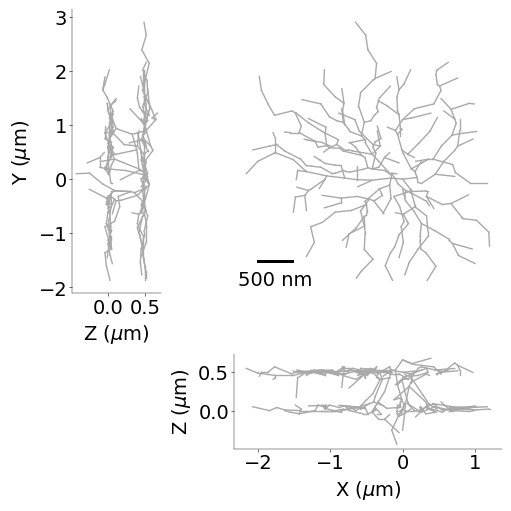

In [8]:
# ----------------------------------------------------------------
# load the example cell "0060_00556_3R_C02_01" with `file_manager`
# from morphology (0.5 pts)
# ----------------------------------------------------------------
filename = "0060_00556_3R_C02_01.swc"
filepath = data_path + filename
neuron = file_manager.load_swc_file(filename=filepath, pca_rot=False, soma_center=False)


# -------------------------------------
# plot all three planar views (0.5 pts)
# -------------------------------------
fig = plt.figure(figsize=(5, 5))
show_threeview(neuron, fig)

### Questions (0.5 pts)

1) Describe the dendritic structure of this neuron. How is it special? Can you even give a technical term for its appearance?

**Answer:**

- **Description of the dendritic structure:** This neuron exhibits a disk-shaped, radially symmetric arbor in the XY plane, with dendrites spreading evenly around the soma. The side views (ZY and XZ) reveal that the dendrites are not uniformly distributed along the depth of the inner plexiform layer (IPL), but instead form two distinct, flat bands. These bands are confined to narrow Z-planes, one above and one below the soma, with very little dendritic material in between.

- **What makes it special:** The presence of two stratified layers makes this neuron bistratified, allowing it to receive inputs from two functionally distinct IPL sublayers, typically corresponding to ON and OFF pathways.

- **Technical term:** This morphology is referred to as a bistratified laminar arbor which is a hallmark of certain retinal ganglion cells specialized for processing both light-onset and light-offset signals.

SWC files are a compact way for storing neural morphologies but their graph structure makes them difficult to handle for current machine learning methods. We, therefore, need to convert our reconstructions into a reasonable vector-like representations. 

Here we will present two commonly chosen representations: Morphometric statistics and density maps


In [9]:
# load all reconstructions. Note: files are sorted by cell number
def load_files(path: str) -> list[nt]:
    """Returns list of NeuronTrees for all .swc files in `path`.
    The reconstructions should be sorted ascendingly by their filename.

    Args:
        path (str): The path to the folder containing the reconstructions.

    Returns:
        list[nt]: An object array of NeuronTrees containing all reconstructions at `path`.
    """
    neurons = []
    # ----------------------------------------------------------
    # use `file_manager` to import all reconstructions (0.5 pts)
    # Note the list should be sorted by filename.
    # ----------------------------------------------------------
    swc_files = sorted(f for f in os.listdir(path) if f.lower().endswith(".swc"))
    for fname in swc_files:
        filepath = os.path.join(path, fname)
        neuron = file_manager.load_swc_file(
            filename=filepath, pca_rot=False, soma_center=False
        )
        neurons.append(neuron)
    return neurons


neurons = load_files(data_path)
print("Number of reconstructions: ", len(neurons))

Number of reconstructions:  550


## Task 2: Morphometric statistics

Morphometric statistics denote a set of hand-crafted single valued features such as `soma radius`, `number of tips` or `average branch angle`. For a more detailed explanation of morphometrics please refer to the [MorphoPy documentation](https://github.com/berenslab/MorphoPy#morphometric-statistics).

*Grading: 4pts*

First, let's compute the feature-based representation for each cell using the function `compute_morphometric_statistics` of the MorphoPy package which computes a predefined set of $28$ statistics.


In [10]:
from morphopy.computation.feature_presentation import compute_morphometric_statistics


# --------------------------------------------------------------------------
# 1. extraction the morphometric statistics for the entire data set (0.5 pts)
# --------------------------------------------------------------------------
swc_files = sorted([f for f in os.listdir(data_path) if f.lower().endswith(".swc")])
ms_list = [
    compute_morphometric_statistics(neuron).assign(
        Cell_nr=int((os.path.splitext(fname)[0]).split("_")[0])
    )
    for fname, neuron in zip(swc_files, neurons)
]

# -----------------------------------------------------------------------------------
# 2. concatenate data into one pd.DataFrame and set the `Cell_nr`` as index (0.5 pts)
# -----------------------------------------------------------------------------------

morphometric_statistics = pd.concat(ms_list, ignore_index=True).set_index("Cell_nr")

Now let's visualize the data.

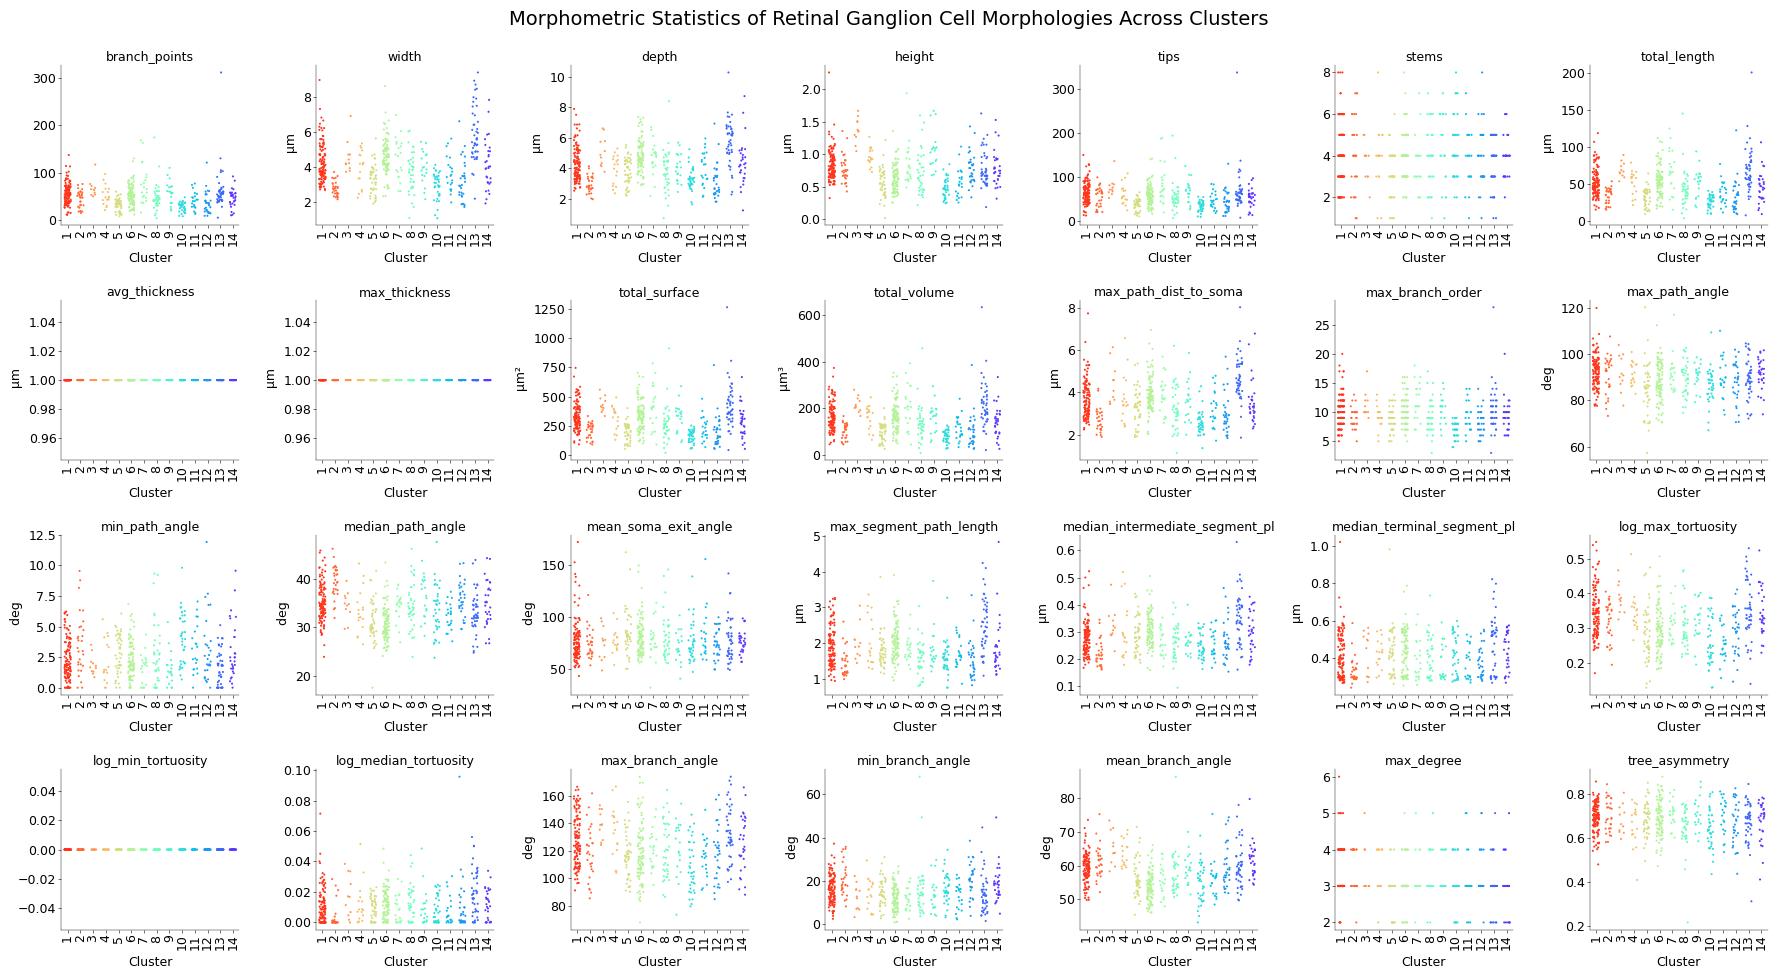

In [11]:
df = (
    morphometric_statistics.reset_index()
    .merge(labels, on="Cell_nr")
    .set_index("Cell_nr")
)

features = morphometric_statistics.columns.values

fig, axes = plt.subplots(4, 7, figsize=(18, 10))
axes = axes.flatten()

# -----------------------------------------------------------
# Create a scatter/strip plot for each morphometric statistic
# showing how it varies across clusters. (2 pts)
# -----------------------------------------------------------
feature_units = {
    "width": "μm",
    "height": "μm",
    "depth": "μm",
    "total_length": "μm",
    "total_surface": "μm²",
    "total_volume": "μm³",
    "max_path_dist_to_soma": "μm",
    "max_segment_path_length": "μm",
    "median_intermediate_segment_pl": "μm",
    "median_terminal_segment_pl": "μm",
    "mean_branch_angle": "deg",
    "min_branch_angle": "deg",
    "max_branch_angle": "deg",
    "median_path_angle": "deg",
    "min_path_angle": "deg",
    "max_path_angle": "deg",
    "avg_thickness": "μm",
    "max_thickness": "μm",
    "log_max_tortuosity": "",
    "log_median_tortuosity": "",
    "log_min_tortuosity": "",
    "branch_points": "",
    "tips": "",
    "stems": "",
    "max_branch_order": "",
    "max_degree": "",
    "tree_asymmetry": "",
    "mean_soma_exit_angle": "deg",
}

for i, feature in enumerate(features):
    ax = axes[i]
    sns.stripplot(
        data=df,
        x="cluster",
        y=feature,
        ax=ax,
        palette=colors,
        size=3,
        jitter=0.25,
    )
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("Cluster", fontsize=9)
    ax.set_ylabel(
        (f" {feature_units[feature]}" if feature_units[feature] != "" else ""),
        fontsize=9,
    )
    ax.tick_params(axis="x", labelrotation=90, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)


# Add main title
fig.suptitle(
    "Morphometric Statistics of Retinal Ganglion Cell Morphologies Across Clusters",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import f_oneway

anova_stats = []
for feat in features:
    groups = [grp[feat].values for _, grp in df.groupby("cluster")]
    F, p = f_oneway(*groups)
    anova_stats.append({"feature": feat, "F_stat": F, "p_value": p})

anova_df = pd.DataFrame(anova_stats).sort_values("F_stat", ascending=False)
print(anova_df)

                           feature     F_stat       p_value
1                            width  22.453216  7.077543e-43
3                           height  19.792955  4.161767e-38
2                            depth  18.332633  2.064073e-35
6                     total_length  16.222915  2.036233e-31
10                    total_volume  16.222915  2.036233e-31
9                    total_surface  16.222915  2.036233e-31
11           max_path_dist_to_soma  15.360768  9.453827e-30
25               mean_branch_angle  13.763381  1.309673e-26
15               median_path_angle  12.680239  1.934272e-24
17         max_segment_path_length  10.190192  2.447109e-19
20              log_max_tortuosity  10.023280  5.445258e-19
18  median_intermediate_segment_pl   9.472563  7.699278e-18
0                    branch_points   9.233723  2.439760e-17
4                             tips   8.823262  1.781358e-16
12                max_branch_order   6.839649  2.872954e-12
14                  min_path_angle   5.7

### Questions (1 pt)

1) Which statistics separate clusters well? Which can be removed? (tips: there are 5 uninformative features)

**Answer:**

By looking at the plots and then running an ANOVA test to get a more quantitative measure of each feature's ability to discriminate between groups, 4 immediately apparent uninformative features are: `log_min_tortuosity`, `mean_soma_exit_angle`, `max_thickness`, and `avg_thickness`. This can be seen from the plots as well as the `NaN` values that appear in the ANOVA test, which happens when both the “between-cluster” and “within-cluster” variances collapse to zero (i.e. the feature is effectively constant across every cell in every cluster and can be dropped outright, since it carries no discriminative information).

In addition, the feature `stems` (F ≈ 2.07, p ≈ 0.014) has very weak discriminative power and can also be considered uninformative. Together, these five features are good candidates for removal.

On the other hand, the best separating features, as shown by high F-statistics and visible separation in the plots, are:

- **Extent & size**: `width`, `height`, `depth`
- **Tree "mass"**: `total_length`, `total_surface`, `total_volume`
- **Soma spread**: `max_path_dist_to_soma`
- **Angle and tortuosity metrics**: `mean_branch_angle`, `median_path_angle`, `log_max_tortuosity`, `max_segment_path_length`

These features show strong between-cluster differences and should be prioritized in downstream analyses.


2) More generally, what do morphometric statistics capture well? What are their advantages, what might be their downsides? Briefly explain.

**Answer:**

**Advantages**
- **Interpretability:** Each feature has a clear biological meaning (e.g. “tips” = number of terminal branches).  
- **Compactness:** Condenses a complex 3D arbor into a manageable vector (here 28 dims).  
- **Robustness:** Hand-crafted features tend to be stable to small tracing errors or noise.  
- **Speed:** Computing 28 summary stats is extremely fast compared to voxelizing or deep-learning approaches.  

**Downsides**
- **Loss of spatial detail:** They throw away fine spatial information, so two cells with very different shapes but similar totals can look identical.  
- **Limited expressivity:** Hand-picked features may miss subtler morphological traits (e.g. local arbor density or curvature patterns).  
- **Potential redundancy:** Some stats can be highly correlated (e.g. `total_surface` vs. `total_volume`), inflating dimensionality without new information.  
- **Feature-engineering bias:** The chosen 28 stats reflect prior notions of “important” morphology; novel or unexpected distinguishing patterns might be overlooked.  


## Task 3: Density maps

Density maps project a neuron's 3D point cloud ($x$, $y$, $z$) onto a plane or an axis, and bin the projected point cloud into a fixed number of bins. Hereby, the binning controls how much global or local information is kept, which majorly affects the results.

**Exercise:** Compute the density maps of all neurons onto all cardinal planes and axes using the method `compute_density_maps`. You can manipulate the parameters for the density maps via the dictonary `config`. 
Make sure that you normalize the density maps globally and bin each direction into $20$ bins.
You are welcome to explore, how the different projections look like but we will only use the z-projection for further analysis.


Possible parameters to pass are:

- `distance`: (default=1, in microns) determines the resampling distance.
- `bin_size`: (default=20, in microns). If set the number of bins will be computed such that one bin 
spans `bin_size` microns. This is overwritten when `n_bins_x/y/z` is set!
- `n_bins_x/y/z`: (default=None) specifies the number of bins for each dimension. If set it will overwrite the 
`bin_size` flag.
- `density`: (default=True) bool to specify if a density or counts are returned.
- `smooth`: (default=True) bool to trigger Gaussian smoothing.
- `sigma`: (default=1) determines std of the Gaussian used for smoothing. The bigger the sigma the more smoothing occurs. If smooth is set to False this parameter is ignored. 
- `r_min_x/y/z`: (in microns) minimum range for binning of x, y, and z. This value will correspond to the 
minimal histogram edge. 
- `r_max_x/y/z`: (in microns) maximum range for binning for x, y, and z. This value will correspond to the 
maximal histogram edge. 

*Grading: 4pts*

In [13]:
# For further analysis we will remove uninformative features and z-score along each statistic
features_to_drop = [
    "avg_thickness",
    "max_thickness",
    "total_surface",
    "total_volume",
    "log_min_tortuosity",
]
morphometric_data = morphometric_statistics.drop(features_to_drop, axis=1)

# z-score morphometrics and remove nans and uninformative features
morphometric_data = (
    morphometric_data - morphometric_data.mean()
) / morphometric_data.std()
morphometric_data[morphometric_data.isna()] = 0
morphometric_data = morphometric_data.values

In [14]:
# ------------------------------------------------------------------------------------
# Find the minimal and maximal x,y,z - coordinates of the reconstructions to normalize
# the density maps globally using r_min_x/y/z and r_max_x/y/z and print them  for
# each direction. (1 pt)
# ------------------------------------------------------------------------------------

x_coords, y_coords, z_coords = [], [], []
for neuron in neurons:
    x_coords.extend(swc["x"].values)
    y_coords.extend(swc["y"].values)
    z_coords.extend(swc["z"].values)

r_min_x, r_max_x = min(x_coords), max(x_coords)
r_min_y, r_max_y = min(y_coords), max(y_coords)
r_min_z, r_max_z = min(z_coords), max(z_coords)

print(f"Min/Max X: {r_min_x:.2f} μm, {r_max_x:.2f} μm")
print(f"Min/Max Y: {r_min_y:.2f} μm, {r_max_y:.2f} μm")
print(f"Min/Max Z: {r_min_z:.2f} μm, {r_max_z:.2f} μm")

Min/Max X: -1.72 μm, 1.73 μm
Min/Max Y: -2.54 μm, 1.84 μm
Min/Max Z: 0.14 μm, 0.63 μm


In [27]:
from morphopy.computation.feature_presentation import compute_density_maps

config_global = dict(
    # ---------------------------------------------------------------------------------
    # complete the config dict and compute the z-density maps for each neuron (1 pts)
    # ---------------------------------------------------------------------------------
    distance=1,
    n_bins_x=20,
    n_bins_y=20,
    n_bins_z=20,
    density=True,
    smooth=True,
    sigma=1,
    r_max_x=r_max_x,  # Global max x
    r_max_y=r_max_y,  # Global max y
    r_max_z=r_max_z,  # Global max z
    r_min_x=r_min_x,  # Global min x
    r_min_y=r_min_y,  # Global min y
    r_min_z=r_min_z,  # Global min z
)

density_maps = [
    compute_density_maps(neuron, config_params=config_global) for neuron in neurons
]

# extract the z density map
dm_z = [dm["z_proj"]["data"] for dm in density_maps]

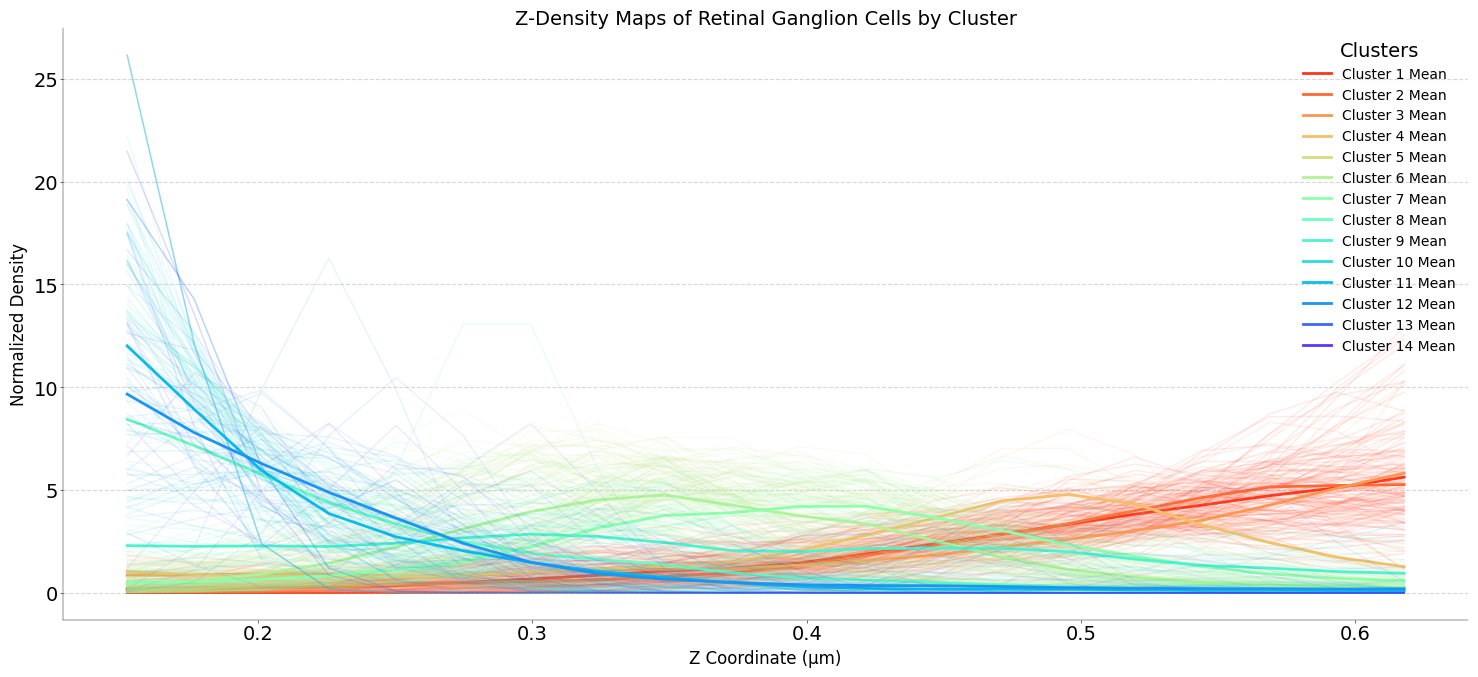

In [31]:
# --------------------------------------------------------------------
# plot the Z-density maps and their means sorted by class label (1 pt)
# Note: make sure the clusters are comparable.
# --------------------------------------------------------------------

# Merge neuron indices with cluster labels
cell_nrs = [
    int(os.path.splitext(f)[0].split("_")[0])
    for f in sorted(os.listdir(data_path))
    if f.lower().endswith(".swc")
]
dm_df = pd.DataFrame({"Cell_nr": cell_nrs, "Z_density": dm_z}).merge(
    labels[["Cell_nr", "cluster"]], on="Cell_nr"
)

# Compute bin edges for z-axis (same for all neurons due to global normalization)
z_bins = np.linspace(r_min_z, r_max_z, 21)  # 20 bins + 1 for edges
z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2  # Midpoints for plotting

# Plot z-density maps
fig, ax = plt.subplots(figsize=(15, 7))

for cluster in sorted(dm_df["cluster"].unique()):
    cluster_data = dm_df[dm_df["cluster"] == cluster]
    cluster_z_densities = np.array(list(cluster_data["Z_density"]))
    # Plot individual density maps (semi-transparent)
    for z_density in cluster_z_densities:
        ax.plot(z_bin_centers, z_density, color=colors[cluster - 1], alpha=0.1)
    # Plot mean density map
    mean_z_density = cluster_z_densities.mean(axis=0)
    ax.plot(
        z_bin_centers,
        mean_z_density,
        color=colors[cluster - 1],
        linewidth=2,
        label=f"Cluster {cluster} Mean",
    )


ax.set_xlabel("Z Coordinate (μm)", fontsize=12)
ax.set_ylabel("Normalized Density", fontsize=12)
ax.set_title("Z-Density Maps of Retinal Ganglion Cells by Cluster", fontsize=14)
ax.legend(title="Clusters", loc="upper right", fontsize=10)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Questions (1 pt)

1) What does the Z-density map tell you about the cell types? Can you identify a trend in the density maps?

**Answer:** The z-density map represents the normalized density of a neuron’s dendritic arbor along the z-axis, corresponding to the depth within the inner plexiform layer (IPL) of the retina. Since the IPL is stratified into ON and OFF sublayers, the z-density map reveals how dendrites are distributed across these functional layers, which is critical for distinguishing retinal ganglion cell (RGC) types. The z-density maps show distinct peaks, indicating where dendrites are concentrated in the IPL. Clusters with single peaks suggest monostratified RGCs, which synapse in either the ON or OFF sublayer (e.g., ON cells deeper in the IPL, OFF cells closer to the ganglion cell layer). Clusters with two peaks (bistratified) indicate RGCs that span both ON and OFF sublayers, processing both light-onset and light-offset signals. Clusters 1-4 have greater density in higher z-depth, cluster 6-8 have greater density in middle z-depth and clusters 9-14 have greater density in lower z-depth. Most cluster means have single peaks suggesting mostly monstratified RGCs.

2) Which cluster(s) would you expect the cell from Task 1 to come from and why?

**Answer:** The cell from Task 1 has a bistratified laminar arbor, with dendrites forming two distinct flat bands in the ZY and XZ views, confined to narrow z-planes above and below the soma. Cluster 9 seems to be the most likely for the cell from task 1 to come from since the identified cell likely belongs to a cluster with a bistratified z-density map, characterized by two distinct peaks in the z-density plot. Cluster 9 mean is relatively uniformly distributed but has slight peaks around 0.28 and 0.48 z-coordinates. 

## Task 4: 2D embedding using t-SNE


Embed both data, the morphometric statistics and the density maps, in 2D using t-SNE and color each embedded point by its cluster assignment.

*Grading: 3 pts*

In [17]:
from openTSNE import TSNE

# ----------------------------------------------------------------------
# Fit t-SNE with morphometric statistics and density maps (0.5 + 0.5 pt)
# Note that this can take a bit to run. (use perplexity=100 
# and a random state of 17)
# ----------------------------------------------------------------------

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# ----------------------------------------------------------------------------
# plot tsne fits for both morpometric statistics and z-projected density maps.
# Color the points appropriately and answer the questions below. (2 pt)
# ----------------------------------------------------------------------------



### Questions:
1) Which representation produces the better clustering? Why could this be the case?

**Answer:**

2) What are the advantages of morphometric statistics over density maps 

**Answer:**

3) What are the advantages of density maps over morphometric statistics 

**Answer:**

## Task 5: Predicting the projection site

The relationship between neuronal morphology and functional specialization is well-established in neurobiology. Hence, we expect distinct functional domains within the thalamus to exhibit corresponding morphological signatures. In this analysis, we aim to predict the thalamic projection site (`labels['projection_site']`) of individual neurons based on their morphological characteristics. Fit a logistic regression on both morphological representations and report its average cross validated (cv=5) prediction accuracy for each. Which representation works better to recover the prediction target? Which features are most relevant for that prediction?

You can use `LogisticRegressionCV` of the scikit-learn library directly. To understand the relevance of individual features plot the fitted linear coefficients. Note, since the classes are imbalanced make sure to report the balanced prediction accuracy.

*Grading: 2 pts*

In [ ]:
from sklearn.linear_model import LogisticRegressionCV


# -----------------------------------------------------------------------------
# Fit a logistic regressor to predict the projection site based on both feature
# representations and print the avg. prediction accuracy (1 pt)
# -----------------------------------------------------------------------------

While Z density maps allow for better recovery of cell type labels, they are worse than morphometric statistics on predicting the projection target. 

In [ ]:
# ---------------------------------------------------------------------------
# Plot the fitted linear coefficients for both of the feature representations
# and answer the question below. (1 pt)
# ---------------------------------------------------------------------------

### Question:

1) Which morphometrics are informative on the projection site?

**Answer:**

## Further references

Other ways to represent and compare morphologies are
* Persistence: [Description](https://link.springer.com/article/10.1007/s12021-017-9341-1) and [application on somatosensory pyramidal cell dendrites](https://academic.oup.com/cercor/article/29/4/1719/5304727) by Kanari et al. 2018

* Tree edit distance: [Heumann et al. 2009](https://link.springer.com/article/10.1007/s12021-009-9051-4)

* Sequential encoding inspired by BLAST: [Encoding](https://link.springer.com/article/10.1186/s12859-015-0604-2) and [similarity analysis on cortical dendrites](https://link.springer.com/article/10.1186/s12859-015-0605-1) by Gilette et al. 2015

* Vector point clouds: [BlastNeuron: Wan et al. 2015](https://link.springer.com/article/10.1007/s12021-015-9272-7)